In [ ]:
## modellskript für minmax und sequenzerstellung
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
# erstelle ein numpy-array mit 10 werten:
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
meinscaler = MinMaxScaler(feature_range=(0, 1))
x_norm = meinscaler.fit_transform(x.reshape(-1, 1))
#print(x_norm)

def create_sequences(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x = data[i:(i + window_size)]
        y = data[i + window_size]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

window_size = 3
X, y = create_sequences(x_norm, window_size)
# einzelne datensätze ausdrucken:
print(X[0], y[0])
print(X[1], y[1])
print(X[2], y[2])
print(X[3], y[3])


[[-1. ]
 [-0.8]
 [-0.6]] [-0.4]
[[-0.8]
 [-0.6]
 [-0.4]] [-0.2]
[[-0.6]
 [-0.4]
 [-0.2]] [0.]
[[-0.4]
 [-0.2]
 [ 0. ]] [0.2]


Sequential(
  (0): Conv1d(1, 18, kernel_size=(3,), stride=(1,), padding=(1,))
  (1): ReLU()
  (2): Conv1d(18, 36, kernel_size=(7,), stride=(1,), padding=(3,))
  (3): ReLU()
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=648, out_features=1, bias=True)
)
Epoch [50/900], Loss: 0.002078
Epoch [100/900], Loss: 0.001253
Epoch [150/900], Loss: 0.000758
Epoch [200/900], Loss: 0.000655
Epoch [250/900], Loss: 0.000594
Epoch [300/900], Loss: 0.000538
Epoch [350/900], Loss: 0.000478
Epoch [400/900], Loss: 0.000416
Epoch [450/900], Loss: 0.000361
Epoch [500/900], Loss: 0.000309
Epoch [550/900], Loss: 0.000271
Epoch [600/900], Loss: 0.000242
Epoch [650/900], Loss: 0.000223
Epoch [700/900], Loss: 0.000202
Epoch [750/900], Loss: 0.000188
Epoch [800/900], Loss: 0.000175
Epoch [850/900], Loss: 0.000175
Epoch [900/900], Loss: 0.000154


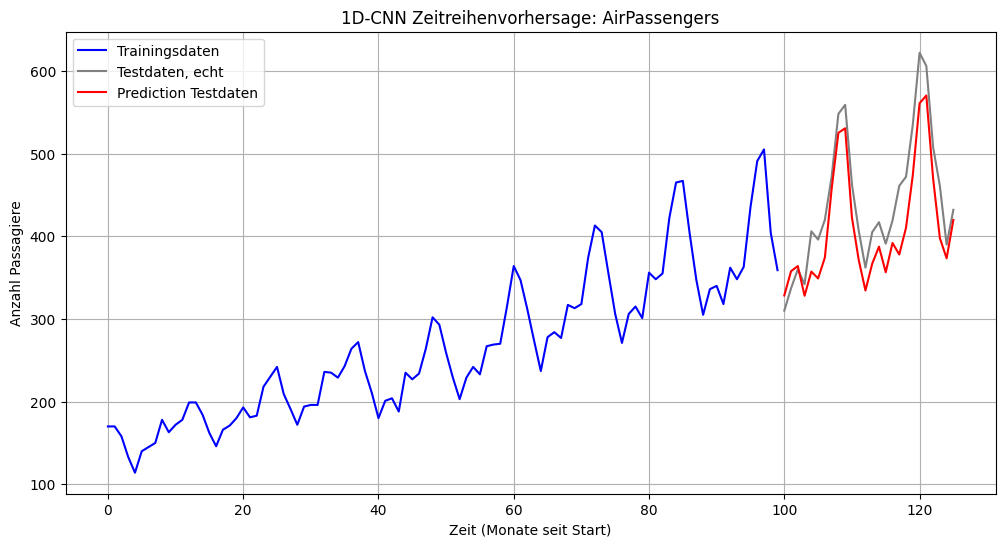

In [49]:
# --- 1. Bibliotheken laden ---
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# --- 2. Daten laden und vorbereiten ---
df = pd.read_csv("AirPassengers.csv")
data = df['Passengers'].values.astype(np.float32).reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_normalized = scaler.fit_transform(data)

# --- 3. Zeitfenster erstellen (Sequenzbildung) ---
# Eine CNN benötigt Eingabesequenzen (X) und einen Zielwert (y).
# Wir erstellen "rollierende Fenster" aus den Daten.
# Beispiel: Mit den Daten [1, 2, 3, 4, 5] und window_size=3 werden folgende Paare erzeugt:
# X = [[1, 2, 3]], y = [4]
# X = [[2, 3, 4]], y = [5]
def create_sequences(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x = data[i:(i + window_size)]
        y = data[i + window_size]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


window_size = 18  # Wir verwenden die letzten 12 Monate, um den nächsten vorherzusagen.
X, y = create_sequences(data_normalized, window_size)

# --- 4. Daten in PyTorch-Tensors umwandeln ---
# PyTorch benötigt als Eingabe das Format: [Batch-Größe, Kanäle, Sequenzlänge]
# Unsere X-Daten haben aktuell das Format: [Batch-Größe, Sequenzlänge, Features/Kanäle]
#
# Analogie zu 2D-CNNs (Bilder):
# - Ein Bild hat [Höhe, Breite, Farbkanäle]. PyTorch erwartet [Farbkanäle, Höhe, Breite]
# - Die Zeitreihe hat [SeqLänge, FeatureChann]. PyTorch erwartet [FeatureChann, SeqLänge]
# Daher müssen wir die letzten beiden Dimensionen tauschen (permutieren).
X_tensor = torch.from_numpy(X).float()
X_tensor = X_tensor.permute(0, 2, 1) # von [131, 12, 1] nach [131, 1, 12]
y_tensor = torch.from_numpy(y).float()

# --- 5. Train-Test-Split ---
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
y_train, y_test = y_tensor[:split], y_tensor[split:]

# --- 6. Modell definieren —
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=18, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv1d(18, out_channels=36, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(window_size * 36, 1)
)
print(model)

# --- 7. Criterion und Optimizer festsetzen ---
loss_fn = nn.MSELoss() #mean squared error
optimizer = torch.optim.Adam(model.parameters(), lr=0.005) # Lernrate etwas reduziert

# --- 8. Trainingszyklus ---
epochs = 900
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_fn(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

# --- 9. Vorhersage und Evaluation auf dem Test-Set ---
model.eval() 
with torch.no_grad():
    test_predictions_normalized = model(X_test)

# --- 10. Rückskalierung der Daten ---
# Vorhersagen & echte Werte müssen zurück in die ursprüngliche Skala.
test_predictions = scaler.inverse_transform(test_predictions_normalized.numpy())
y_test_original = scaler.inverse_transform(y_test.numpy())
y_original = scaler.inverse_transform(y_tensor.numpy())

# --- 11. Visualisierung ---
plt.figure(figsize=(12, 6))

# Plot der originalen Daten (Trainings-Teil)
train_size = len(y_train)
plt.plot(range(train_size), y_original[:train_size], label='Trainingsdaten', color='blue')

# Plot der echten Test-Werte
test_range = range(train_size, train_size + len(y_test_original))
plt.plot(test_range, y_test_original, label='Testdaten, echt', color='gray')

# Plot der vorhergesagten Test-Werte
plt.plot(test_range, test_predictions, label='Prediction Testdaten', color='red')
plt.title('1D-CNN Zeitreihenvorhersage: AirPassengers')
plt.xlabel('Zeit (Monate seit Start)')
plt.ylabel('Anzahl Passagiere')
plt.legend()
plt.grid(True)
plt.show()

In [52]:
# --- 1. Bibliotheken laden ---
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from joblib import dump

# --- 10.5. Modell und Scaler speichern ---
# Speichern des gesamten Modells (Struktur + Gewichte).
# Die Warnung bezüglich 'weights_only=False' beim Laden ist hierbei zu beachten.
torch.save(model, 'cnn_airpassengers_model.pth')

# Speichern des Scaler-Objekts mit joblib
dump(scaler, 'scaler_airpassengers.joblib')

print("\nModell wurde erfolgreich in 'cnn_airpassengers_model.pth' gespeichert.")
print("Scaler wurde erfolgreich in 'scaler_airpassengers.joblib' gespeichert.")


Modell wurde erfolgreich in 'cnn_airpassengers_model.pth' gespeichert.
Scaler wurde erfolgreich in 'scaler_airpassengers.joblib' gespeichert.


In [51]:
# Laden des Modells
loaded_model = torch.load('cnn_airpassengers_model.pth', weights_only=False)
loaded_model.eval() # Wichtig: In den Evaluationsmodus schalten

# Laden des Scalers
from joblib import load
loaded_scaler = load('scaler_airpassengers.joblib')

Bibliotheken erfolgreich geladen.
Modell und Scaler erfolgreich geladen.
Vorhersage für 12 zukünftige Schritte abgeschlossen.

Vorgehersagte Passagierzahlen:
[356.58331828 335.18979502 340.36704228 360.29354554 405.97952696
 474.78439994 600.66687793 535.76617482 492.05444674 403.51472835
 398.19542426 434.20313992]


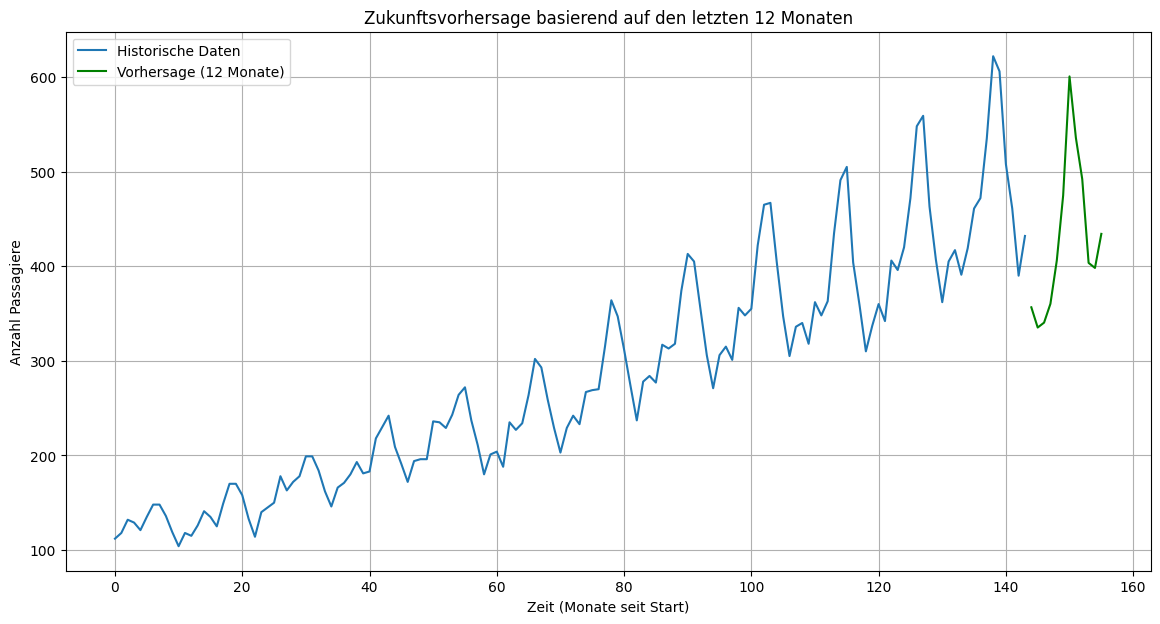

In [ ]:
# --- 1. Bibliotheken laden ---
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load as joblib_load

# --- 2. Konstanten und Dateipfade definieren ---
MODEL_PATH = "cnn_airpassengers_model.pth"
SCALER_PATH = "scaler_airpassengers.joblib"
DATA_PATH = "AirPassengers.csv"
WINDOW_SIZE = 12  # Muss mit dem Training übereinstimmen
NUM_PREDICTIONS = 12 # Anzahl der zukünftigen Monate, die vorhergesagt werden sollen

# --- 3. Modell und Scaler laden ---
model = torch.load(MODEL_PATH, weights_only=False)
model.eval()  # Wichtig: Modell in den Evaluationsmodus schalten

# Lade das Scaler-Objekt
scaler = joblib_load(SCALER_PATH)

# --- 4. Daten laden und Startsequenz vorbereiten ---
df = pd.read_csv(DATA_PATH)
all_data = df['Passengers'].values.astype(np.float32)

# Nimm die letzten 12 Monate aus dem Originaldatensatz als Startpunkt
last_sequence_original = all_data[-WINDOW_SIZE:].reshape(-1, 1)

# Normalisiere diese Startsequenz mit dem geladenen Scaler
last_sequence_normalized = scaler.transform(last_sequence_original)

# Das Modell erwartet die Form [Kanäle, Sequenzlänge], also [1, 12]
# Unser Array hat die Form [12, 1], daher transponieren wir es mit .T
current_sequence = torch.from_numpy(last_sequence_normalized).T

# --- 5. Schrittweise (autoregressive) Vorhersage ---
future_predictions_normalized = []

# Schleife für die schrittweise Vorhersage
for _ in range(NUM_PREDICTIONS):
    with torch.no_grad():
        # Füge eine Batch-Dimension hinzu: [1, 12] -> [1, 1, 12]
        input_tensor = current_sequence.unsqueeze(0)

        # Mache eine Vorhersage
        prediction = model(input_tensor)

        # Speichere den vorhergesagten Wert
        future_predictions_normalized.append(prediction.item())

        # Aktualisiere die Sequenz: Ältesten Wert entfernen, neuesten hinzufügen
        new_value_tensor = prediction.view(1, 1)
        current_sequence = torch.cat((current_sequence[:, 1:], new_value_tensor), dim=1)

print(f"Vorhersage für {NUM_PREDICTIONS} zukünftige Schritte abgeschlossen.")

# --- 6. Rückskalierung und Visualisierung ---
future_predictions_np = np.array(future_predictions_normalized).reshape(-1, 1)

# Skaliere die Werte zurück in die ursprüngliche Passagier-Anzahl
future_predictions = scaler.inverse_transform(future_predictions_np)

print("\nVorgehersagte Passagierzahlen:")
print(future_predictions.flatten())

# Visualisierung
plt.figure(figsize=(14, 7))
plt.title('Zukunftsvorhersage basierend auf den letzten 12 Monaten')
plt.ylabel('Anzahl Passagiere')
plt.xlabel('Zeit (Monate seit Start)')
plt.grid(True)

# Plot der historischen Daten
plt.plot(df.index, df['Passengers'], label='Historische Daten')

# Erstelle den x-Achsen-Bereich für die Vorhersage
forecast_range = range(len(df), len(df) + NUM_PREDICTIONS)

# Plot der Vorhersage
plt.plot(forecast_range, future_predictions, label=f'Vorhersage ({NUM_PREDICTIONS} Monate)', color='green')
plt.legend()
plt.show()


Vorhersage für die nächsten 36 Monate:
[383.4571444  373.89694544 311.75608442 333.56049493 359.85321879
 392.57900806 485.30725697 563.82108566 560.0769111  459.70973471
 459.87979534 418.763715   418.78177699 392.23153848 293.10480438
 294.7587892  301.08014812 337.13399134 443.08806725 531.7685457
 509.44543172 396.34630814 453.34088972 470.36980115 502.87098873
 437.99409041 301.62427732 293.76815819 289.81008021 306.53829801
 405.35195752 496.83883787 472.5472751  336.27865549 415.81340376
 533.04409311]


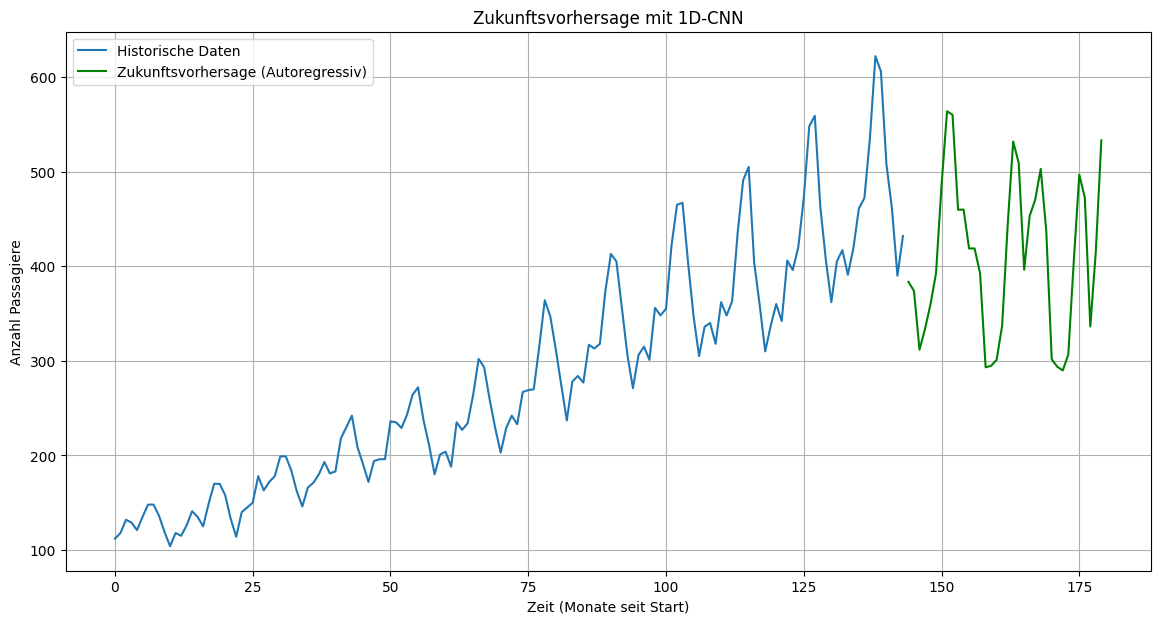

In [17]:
# --- 12. Schrittweise Vorhersage (Autoregressive Inferenz) ---

# Anzahl der zukünftigen Schritte, die wir vorhersagen möchten
num_predictions = 36 # z.B. für die nächsten 3 Jahre

# Wir starten mit der letzten Sequenz aus dem Testdatensatz
# Diese ist bereits normalisiert und im richtigen Tensor-Format
last_sequence_normalized = X_test[-1]

# Liste zum Speichern der normalisierten Vorhersagen
future_predictions_normalized = []

# Die Startsequenz für unsere Schleife
current_sequence = last_sequence_normalized.clone().detach()

# Modell in den Evaluationsmodus schalten (wichtig!)
loaded_model.eval()

# Schleife für die schrittweise Vorhersage
for _ in range(num_predictions):
    with torch.no_grad():
        # Das Modell benötigt ein Batch-Format [Batch, Kanäle, Sequenzlänge],
        # daher fügen wir mit .unsqueeze(0) eine Dimension hinzu.
        # current_sequence hat die Form [1, 12] -> input_tensor hat die Form [1, 1, 12]
        input_tensor = current_sequence.unsqueeze(0)

        # Mache eine Vorhersage
        prediction_normalized = loaded_model(input_tensor)

        # Speichere den vorhergesagten Wert (als einfachen Zahlenwert)
        future_predictions_normalized.append(prediction_normalized.item())

        # --- Sequenz aktualisieren: Ältesten Wert entfernen, neuesten hinzufügen ---
        # Die Vorhersage hat die Form [[wert]], wir formen sie zu [1, 1] um
        new_value_tensor = prediction_normalized.view(1, 1)

        # Wir entfernen den ersten Wert der Sequenz und hängen den neuen Wert an.
        # current_sequence[:, 1:] nimmt alle bis auf das erste Element.
        current_sequence = torch.cat((current_sequence[:, 1:], new_value_tensor), dim=1)

# Rückskalierung der Vorhersagen in die ursprüngliche Dimension
future_predictions_np = np.array(future_predictions_normalized).reshape(-1, 1)
future_predictions = loaded_scaler.inverse_transform(future_predictions_np)

print(f"\nVorhersage für die nächsten {num_predictions} Monate:")
print(future_predictions.flatten())


# --- 13. Visualisierung der Zukunftsvorhersage ---
plt.figure(figsize=(14, 7))

# Plot der originalen, gesamten Datenreihe
# Wir nutzen den ursprünglichen DataFrame df für die historischen Daten
plt.plot(df.index, df['Passengers'], label='Historische Daten')

# Erstelle den Zeit-Index für die Zukunftsvorhersage
# Er beginnt nach dem Ende der historischen Daten
forecast_range = range(len(df), len(df) + num_predictions)

# Plot der Vorhersage
plt.plot(forecast_range, future_predictions, label='Zukunftsvorhersage (Autoregressiv)', color='green')

plt.title('Zukunftsvorhersage mit 1D-CNN')
plt.xlabel('Zeit (Monate seit Start)')
plt.ylabel('Anzahl Passagiere')
plt.legend()
plt.grid(True)
plt.show()

Sequential(
  (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (1): ReLU()
  (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (3): ReLU()
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=384, out_features=3, bias=True)
)
Epoch [50/500], Loss: 0.001947
Epoch [100/500], Loss: 0.000756
Epoch [150/500], Loss: 0.000609
Epoch [200/500], Loss: 0.000515
Epoch [250/500], Loss: 0.000488
Epoch [300/500], Loss: 0.000453
Epoch [350/500], Loss: 0.000433
Epoch [400/500], Loss: 0.000421
Epoch [450/500], Loss: 0.000456
Epoch [500/500], Loss: 0.000388


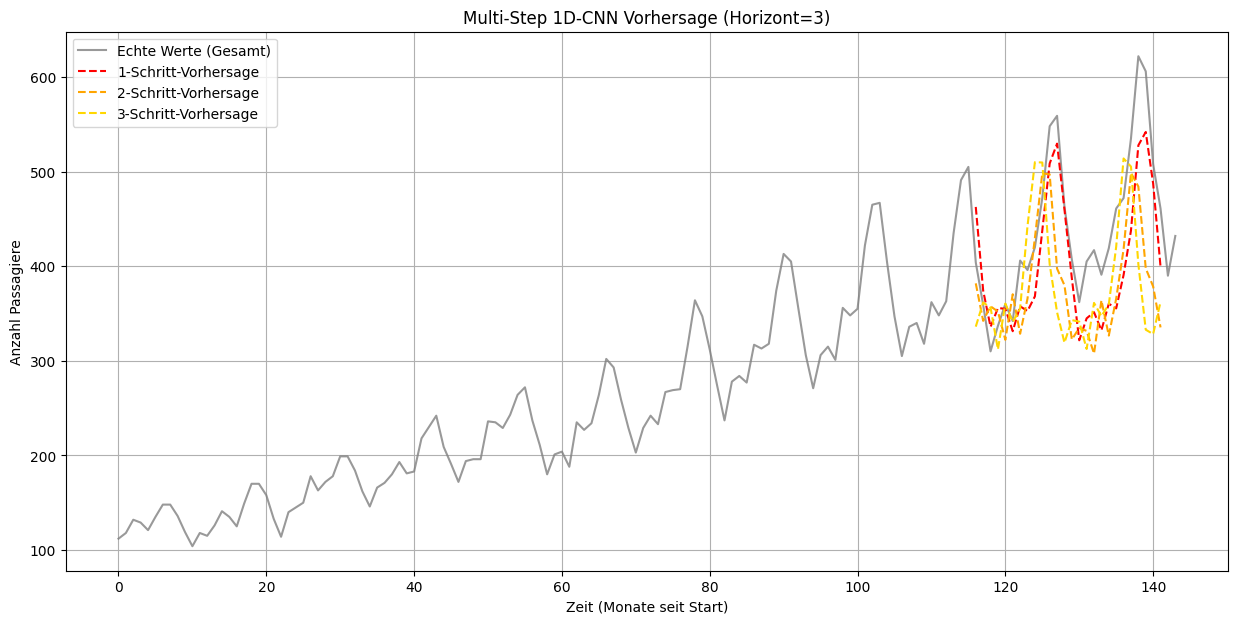

In [3]:
# --- 1. Bibliotheken laden ---
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# --- 2. Daten laden und vorbereiten ---
df = pd.read_csv("AirPassengers.csv")
data = df['Passengers'].values.astype(np.float32).reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_normalized = scaler.fit_transform(data)

# --- 3. Zeitfenster erstellen (Sequenzbildung) ---
# **NEU: Wir definieren einen Vorhersagehorizont.**
# Dies bestimmt, wie viele Zeitschritte in die Zukunft wir vorhersagen wollen.
window_size = 12
prediction_horizon = 3

# **MODIFIZIERT: Die Funktion erzeugt nun Sequenzen als Label.**
def create_sequences(data, window_size, horizon):
    xs, ys = [], []
    # Die Schleife muss früher enden, um Platz für den Horizont zu haben.
    for i in range(len(data) - window_size - horizon + 1):
        x = data[i:(i + window_size)]
        # Das Label y ist jetzt eine Sequenz der Länge 'horizon'.
        y = data[i + window_size:i + window_size + horizon]
        xs.append(x)
        ys.append(y)
    # y muss von (Anzahl, Horizont, 1) auf (Anzahl, Horizont) reduziert werden.
    return np.array(xs), np.array(ys).reshape(-1, horizon)

X, y = create_sequences(data_normalized, window_size, prediction_horizon)

# --- 4. Daten in PyTorch-Tensors umwandeln ---
X_tensor = torch.from_numpy(X).float().permute(0, 2, 1)
y_tensor = torch.from_numpy(y).float()

# --- 5. Train-Test-Split ---
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
y_train, y_test = y_tensor[:split], y_tensor[split:]

# --- 6. Modell definieren ---
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(window_size * 32, prediction_horizon)
)
print(model)

# --- 7. Criterion und Optimizer festsetzen ---
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# --- 8. Trainingszyklus ---
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_fn(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

# --- 9. Vorhersage und Evaluation ---
model.eval()
with torch.no_grad():
    test_predictions_normalized = model(X_test)

# --- 10. Rückskalierung der Daten ---
test_predictions = scaler.inverse_transform(test_predictions_normalized.numpy())
y_test_original = scaler.inverse_transform(y_test.numpy())
full_original_data = scaler.inverse_transform(data_normalized)

# --- 11. Verbesserte Visualisierung für Multi-Step ---
plt.figure(figsize=(15, 7))
train_size = len(y_train)

# Plot der originalen Daten (gesamte Zeitreihe)
plt.plot(full_original_data, label='Echte Werte (Gesamt)', color='gray', alpha=0.8)

# Der x-Achsen-Bereich für die Vorhersagen
test_range = range(train_size + window_size, train_size + window_size + len(test_predictions))

# **MODIFIZIERT: Plot für jeden Schritt des Vorhersagehorizonts.**
# Dies zeigt, wie die Genauigkeit mit zunehmendem Horizont abnimmt.
plt.plot(test_range, test_predictions[:, 0], label='1-Schritt-Vorhersage', color='red', linestyle='--')
plt.plot(test_range, test_predictions[:, 1], label='2-Schritt-Vorhersage', color='orange', linestyle='--')
plt.plot(test_range, test_predictions[:, 2], label='3-Schritt-Vorhersage', color='gold', linestyle='--')

plt.title('Multi-Step 1D-CNN Vorhersage (Horizont=3)')
plt.xlabel('Zeit (Monate seit Start)')
plt.ylabel('Anzahl Passagiere')
plt.legend()
plt.grid(True)
plt.show()